# ABSA dataset study

This notebook studies the train and development JSON files for the ABSA task.

It focuses on two questions:

- How many aspect labels appear in each comment.
- How the comments are distributed by language.

## What we count

Each record has a `gold` object with the aspect-level annotations for that comment.
For this study, the number of predictions per comment is the number of labels stored in `gold`.

In [1]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR = Path('..') / 'dataset'
TRAIN_PATH = DATA_DIR / 'train.json'
DEVEL_PATH = DATA_DIR / 'devel.json'

def load_json(path):
    with open(path, encoding='utf-8') as handle:
        return json.load(handle)

train = load_json(TRAIN_PATH)
devel = load_json(DEVEL_PATH)
all_examples = [('train', item) for item in train] + [('devel', item) for item in devel]

print(f'Train comments: {len(train)}')
print(f'Development comments: {len(devel)}')
print(f'Total comments: {len(all_examples)}')

Train comments: 1056
Development comments: 132
Total comments: 1188


In [2]:
def label_count(example):
    return len(example.get('gold', {}))

def summarize(split_name, examples):
    counts = [label_count(example) for example in examples]
    language_counts = Counter(example.get('language', 'unknown') for example in examples)
    distribution = Counter(counts)

    print(f'\n{split_name.upper()}')
    print(f'  average labels per comment: {sum(counts) / len(counts):.2f}')
    print(f'  min labels per comment: {min(counts)}')
    print(f'  max labels per comment: {max(counts)}')
    print(f'  language counts: {dict(language_counts)}')
    print(f'  label-count distribution: {dict(sorted(distribution.items()))}')

    return counts, language_counts, distribution

train_counts, train_languages, train_distribution = summarize('train', train)
devel_counts, devel_languages, devel_distribution = summarize('devel', devel)

all_counts = train_counts + devel_counts
all_languages = Counter(example.get('language', 'unknown') for _, example in all_examples)
all_distribution = Counter(all_counts)

print('\nOVERALL')
print(f'  average labels per comment: {sum(all_counts) / len(all_counts):.2f}')
print(f'  min labels per comment: {min(all_counts)}')
print(f'  max labels per comment: {max(all_counts)}')
print(f'  language counts: {dict(all_languages)}')
print(f'  label-count distribution: {dict(sorted(all_distribution.items()))}')


TRAIN
  average labels per comment: 3.55
  min labels per comment: 0
  max labels per comment: 10
  language counts: {'en': 343, 'es': 713}
  label-count distribution: {0: 29, 1: 58, 2: 130, 3: 289, 4: 303, 5: 163, 6: 62, 7: 16, 8: 3, 9: 2, 10: 1}

DEVEL
  average labels per comment: 3.44
  min labels per comment: 0
  max labels per comment: 8
  language counts: {'es': 91, 'en': 41}
  label-count distribution: {0: 3, 1: 13, 2: 14, 3: 37, 4: 35, 5: 21, 6: 7, 7: 1, 8: 1}

OVERALL
  average labels per comment: 3.54
  min labels per comment: 0
  max labels per comment: 10
  language counts: {'en': 384, 'es': 804}
  label-count distribution: {0: 32, 1: 71, 2: 144, 3: 326, 4: 338, 5: 184, 6: 69, 7: 17, 8: 4, 9: 2, 10: 1}


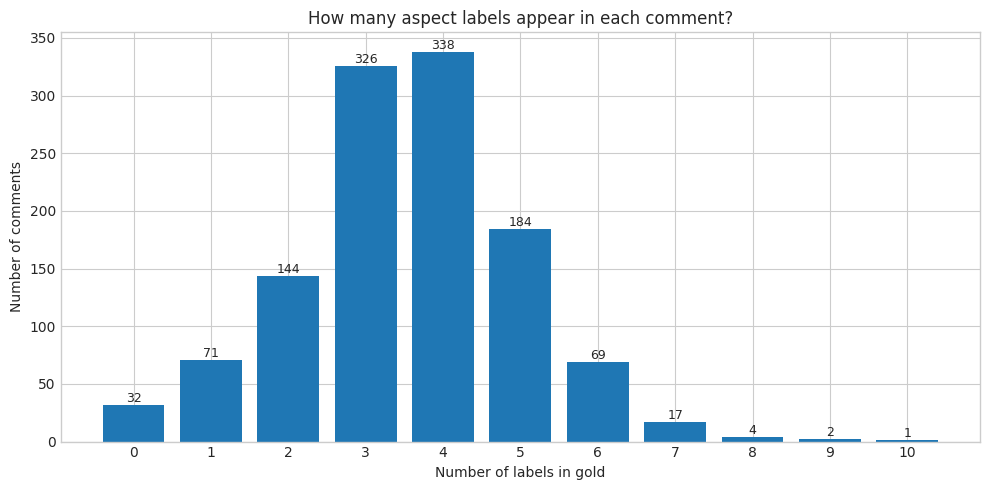

In [3]:
max_labels = max(all_distribution)
x_values = list(range(max_labels + 1))
y_values = [all_distribution.get(label_count_value, 0) for label_count_value in x_values]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x_values, y_values, color='#1f77b4')
ax.set_title('How many aspect labels appear in each comment?')
ax.set_xlabel('Number of labels in gold')
ax.set_ylabel('Number of comments')
ax.set_xticks(x_values)

for bar, value in zip(bars, y_values):
    if value > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, value, str(value), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

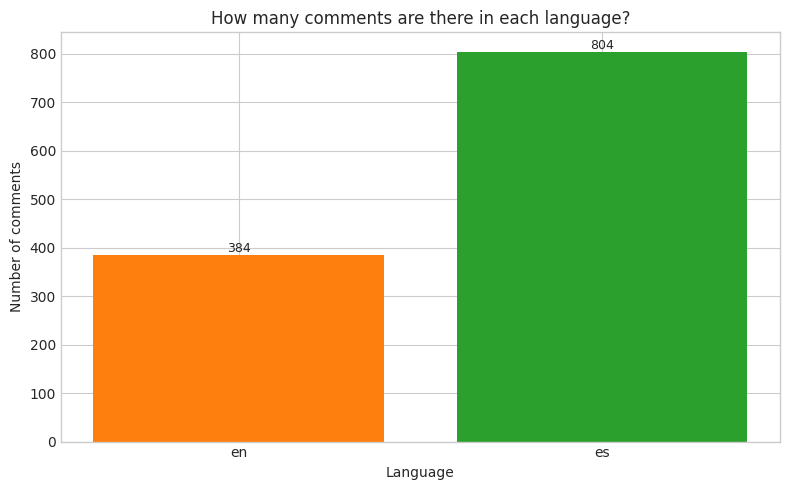

In [4]:
languages = sorted(all_languages)
language_values = [all_languages[language] for language in languages]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(languages, language_values, color=['#ff7f0e', '#2ca02c'][:len(languages)])
ax.set_title('How many comments are there in each language?')
ax.set_xlabel('Language')
ax.set_ylabel('Number of comments')

for bar, value in zip(bars, language_values):
    ax.text(bar.get_x() + bar.get_width() / 2, value, str(value), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Notes

If you want, this notebook can be extended with per-dataset comparisons, aspect-type frequencies, or sentiment breakdowns by language.

## Per-dataset comparison

This section compares train and development split statistics side by side.

TRAIN: 1056 comments, 3.55 labels/comment
  languages: {'en': 343, 'es': 713}
DEVEL: 132 comments, 3.44 labels/comment
  languages: {'es': 91, 'en': 41}


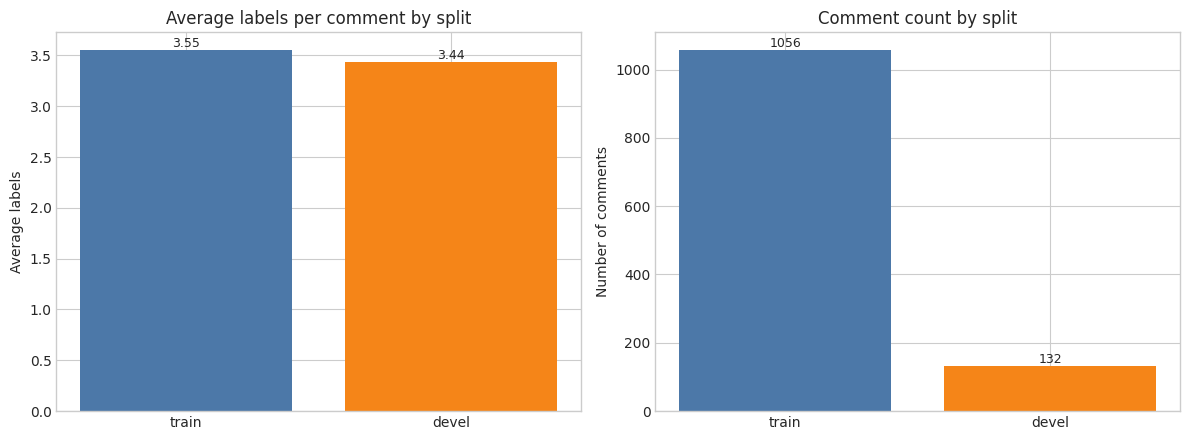

In [5]:
split_stats = {
    'train': {
        'comments': len(train),
        'avg_labels': sum(train_counts) / len(train_counts),
        'languages': train_languages,
    },
    'devel': {
        'comments': len(devel),
        'avg_labels': sum(devel_counts) / len(devel_counts),
        'languages': devel_languages,
    },
}

for split_name, stats in split_stats.items():
    print(f"{split_name.upper()}: {stats['comments']} comments, {stats['avg_labels']:.2f} labels/comment")
    print(f"  languages: {dict(stats['languages'])}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

split_names = list(split_stats)
avg_labels = [split_stats[name]['avg_labels'] for name in split_names]
comments = [split_stats[name]['comments'] for name in split_names]

axes[0].bar(split_names, avg_labels, color=['#4c78a8', '#f58518'])
axes[0].set_title('Average labels per comment by split')
axes[0].set_ylabel('Average labels')
for index, value in enumerate(avg_labels):
    axes[0].text(index, value, f'{value:.2f}', ha='center', va='bottom', fontsize=9)

axes[1].bar(split_names, comments, color=['#4c78a8', '#f58518'])
axes[1].set_title('Comment count by split')
axes[1].set_ylabel('Number of comments')
for index, value in enumerate(comments):
    axes[1].text(index, value, str(value), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Aspect-type frequencies

This section shows which aspect categories appear most often across the two splits.

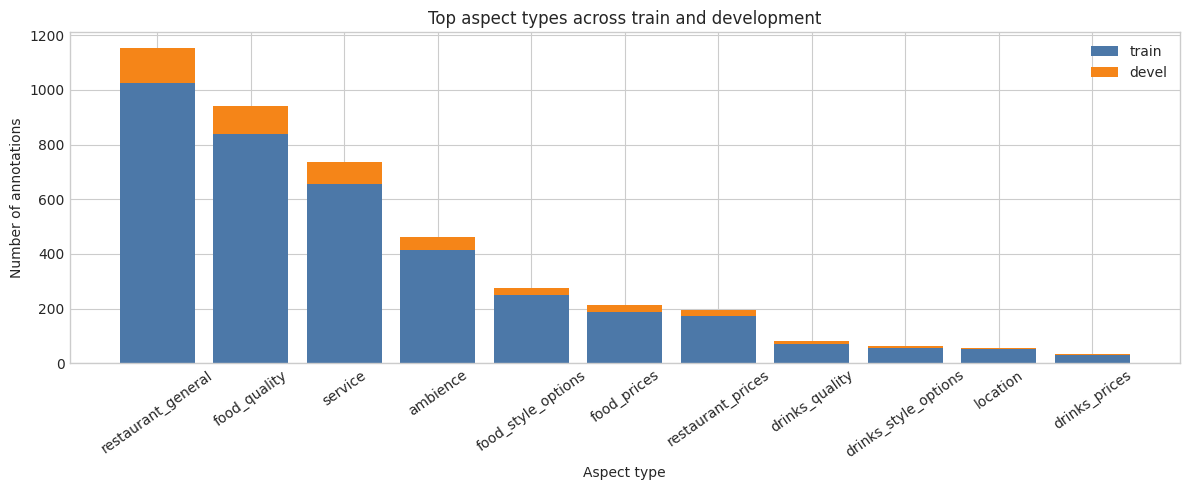

Top aspect frequencies:
restaurant_general        1153
food_quality              940
service                   736
ambience                  460
food_style_options        274
food_prices               212
restaurant_prices         195
drinks_quality            81
drinks_style_options      62
location                  55
drinks_prices             34


In [6]:
def aspect_frequencies(examples):
    counter = Counter()
    for example in examples:
        counter.update(example.get('gold', {}).keys())
    return counter

train_aspects = aspect_frequencies(train)
devel_aspects = aspect_frequencies(devel)
all_aspects = train_aspects + devel_aspects

top_aspects = all_aspects.most_common(12)
labels = [label for label, _ in top_aspects]
train_values = [train_aspects.get(label, 0) for label in labels]
devel_values = [devel_aspects.get(label, 0) for label in labels]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(labels, train_values, label='train', color='#4c78a8')
ax.bar(labels, devel_values, bottom=train_values, label='devel', color='#f58518')
ax.set_title('Top aspect types across train and development')
ax.set_xlabel('Aspect type')
ax.set_ylabel('Number of annotations')
ax.tick_params(axis='x', rotation=35)
ax.legend()
plt.tight_layout()
plt.show()

print('Top aspect frequencies:')
for aspect_name, count in top_aspects:
    print(f'{aspect_name:25s} {count}')

## Sentiment breakdown by language

This section counts the sentiment labels in `gold` and compares them by language.

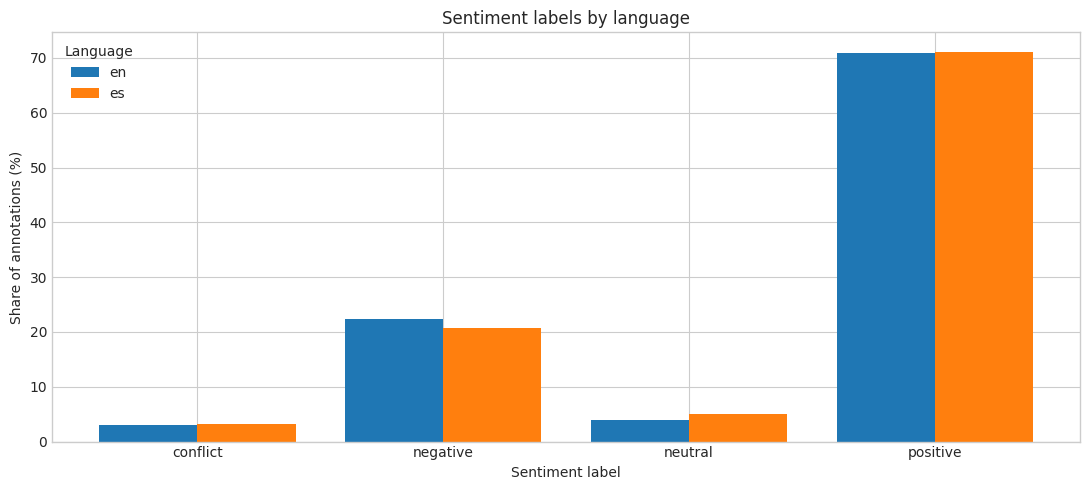

en: {'positive': 70.9, 'negative': 22.3, 'conflict': 3.0, 'neutral': 3.9}
es: {'positive': 71.1, 'negative': 20.7, 'conflict': 3.2, 'neutral': 5.0}


In [16]:
def sentiment_by_language(examples):
    result = {}
    for example in examples:
        language = example.get('language', 'unknown')
        result.setdefault(language, Counter())
        result[language].update(example.get('gold', {}).values())
    return result

sentiment_counts_by_language = sentiment_by_language([example for _, example in all_examples])
all_sentiments = sorted({sentiment for counts in sentiment_counts_by_language.values() for sentiment in counts})
language_order = sorted(sentiment_counts_by_language)

fig, ax = plt.subplots(figsize=(11, 5))
bar_width = 0.8 / max(len(language_order), 1)
positions = list(range(len(all_sentiments)))

for index, language in enumerate(language_order):
    total = sum(sentiment_counts_by_language[language].values())
    values = [100.0 * sentiment_counts_by_language[language].get(sentiment, 0) / total for sentiment in all_sentiments]
    offsets = [position + index * bar_width for position in positions]
    ax.bar(offsets, values, width=bar_width, label=language)

ax.set_title('Sentiment labels by language')
ax.set_xlabel('Sentiment label')
ax.set_ylabel('Share of annotations (%)')
ax.set_xticks([position + bar_width * (len(language_order) - 1) / 2 for position in positions])
ax.set_xticklabels(all_sentiments)
ax.legend(title='Language')
plt.tight_layout()
plt.show()

for language in language_order:
    total = sum(sentiment_counts_by_language[language].values())
    normalized = {
        sentiment: round(100.0 * count / total, 1)
        for sentiment, count in sentiment_counts_by_language[language].items()
    }
    print(f'{language}: {normalized}')

## Average labels per comment by language

This compares how densely comments are annotated in English and Spanish.

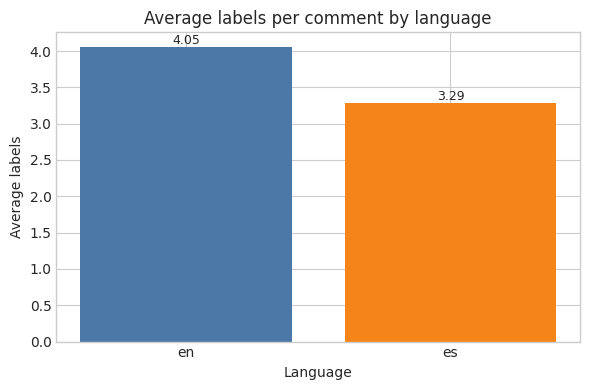

{'en': '4.05', 'es': '3.29'}


In [9]:
labels_by_language = {}
for language in language_order:
    labels_by_language[language] = [len(example.get('gold', {})) for _, example in all_examples if example.get('language', 'unknown') == language]

language_averages = {language: (sum(values) / len(values)) for language, values in labels_by_language.items()}

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(language_order, [language_averages[language] for language in language_order], color=['#4c78a8', '#f58518'][:len(language_order)])
ax.set_title('Average labels per comment by language')
ax.set_xlabel('Language')
ax.set_ylabel('Average labels')

for index, language in enumerate(language_order):
    value = language_averages[language]
    ax.text(index, value, f'{value:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print({language: f'{language_averages[language]:.2f}' for language in language_order})

## Label-count histogram by language

This shows whether one language tends to have more or fewer aspect labels per comment.

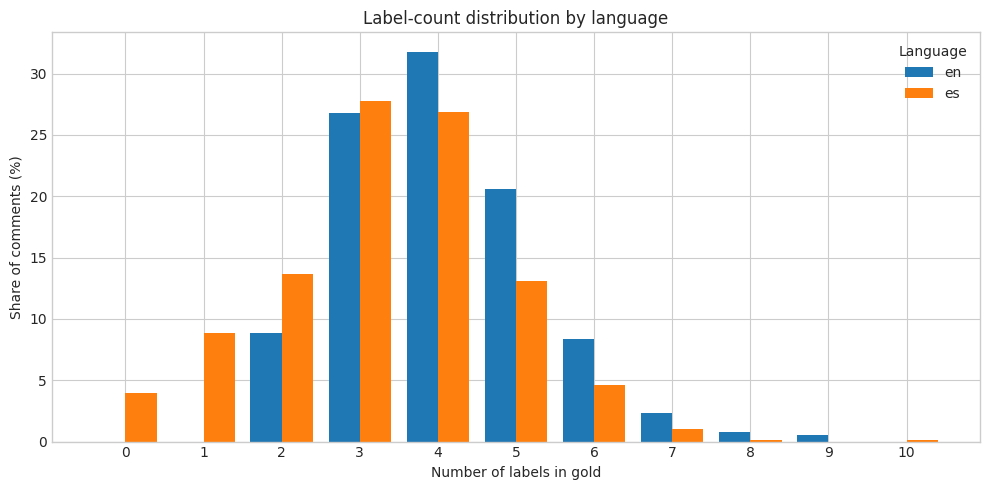

In [15]:
max_labels_by_language = max(max(values) for values in labels_by_language.values())
count_bins = list(range(max_labels_by_language + 1))
bar_width = 0.8 / max(len(language_order), 1)

fig, ax = plt.subplots(figsize=(10, 5))
for index, language in enumerate(language_order):
    counts = Counter(labels_by_language[language])
    total = len(labels_by_language[language])
    values = [100.0 * counts.get(label_count_value, 0) / total for label_count_value in count_bins]
    offsets = [label_count_value + index * bar_width for label_count_value in count_bins]
    ax.bar(offsets, values, width=bar_width, label=language)

ax.set_title('Label-count distribution by language')
ax.set_xlabel('Number of labels in gold')
ax.set_ylabel('Share of comments (%)')
ax.set_xticks([label_count_value + bar_width * (len(language_order) - 1) / 2 for label_count_value in count_bins])
ax.set_xticklabels(count_bins)
ax.legend(title='Language')
plt.tight_layout()
plt.show()

## Sentiment distribution per aspect

This shows how the sentiment labels are distributed for the most frequent aspect types.

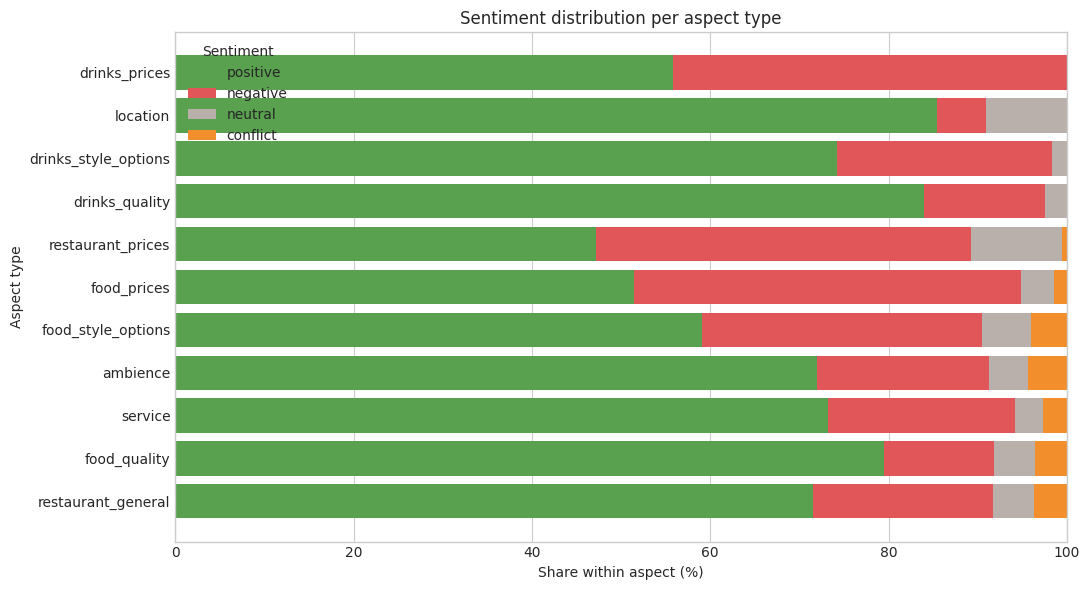

In [17]:
aspect_sentiment = Counter()
for _, example in all_examples:
    gold = example.get('gold', {})
    for aspect_name, sentiment in gold.items():
        aspect_sentiment[(aspect_name, sentiment)] += 1

sentiment_labels = ['positive', 'negative', 'neutral', 'conflict']
aspect_order = [aspect_name for aspect_name, _ in all_aspects.most_common()]

plot_data = []
for aspect_name in aspect_order:
    total = sum(aspect_sentiment.get((aspect_name, sentiment_label), 0) for sentiment_label in sentiment_labels)
    if total == 0:
        continue
    row = [100.0 * aspect_sentiment.get((aspect_name, sentiment_label), 0) / total for sentiment_label in sentiment_labels]
    plot_data.append(row)

fig, ax = plt.subplots(figsize=(11, max(6, 0.35 * len(aspect_order))))
left = [0.0] * len(plot_data)
colors = {'positive': '#59a14f', 'negative': '#e15759', 'neutral': '#bab0ab', 'conflict': '#f28e2b'}

for sentiment_index, sentiment_label in enumerate(sentiment_labels):
    values = [row[sentiment_index] for row in plot_data]
    ax.barh(aspect_order[:len(plot_data)], values, left=left, label=sentiment_label, color=colors[sentiment_label])
    left = [current + value for current, value in zip(left, values)]

ax.set_title('Sentiment distribution per aspect type')
ax.set_xlabel('Share within aspect (%)')
ax.set_ylabel('Aspect type')
ax.legend(title='Sentiment')
plt.tight_layout()
plt.show()

## Aspect vs sentiment heatmap

This condenses the full aspect-sentiment matrix into a single overview.

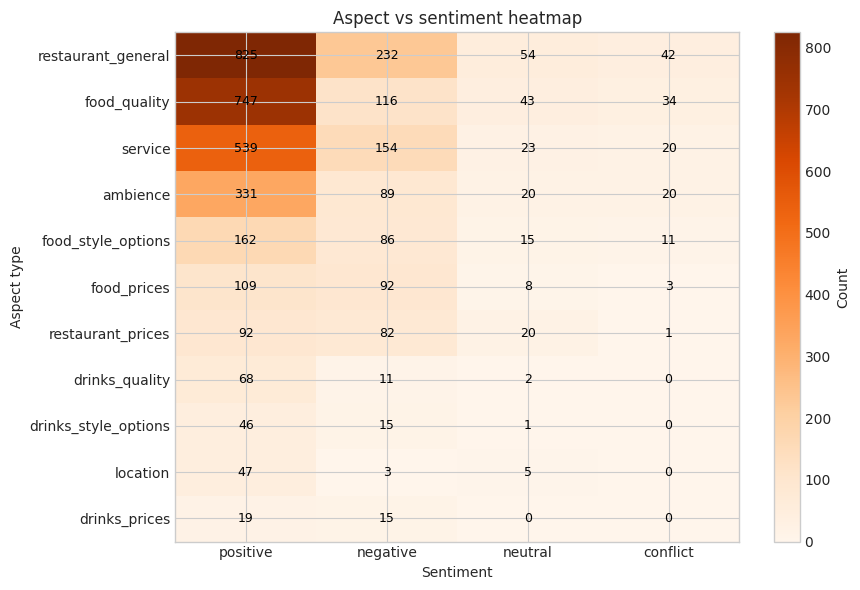

In [18]:
aspect_order = [aspect_name for aspect_name, _ in all_aspects.most_common()]
heatmap_matrix = [[aspect_sentiment.get((aspect_name, sentiment_label), 0) for sentiment_label in sentiment_labels] for aspect_name in aspect_order]

fig, ax = plt.subplots(figsize=(9, max(6, 0.35 * len(aspect_order))))
im = ax.imshow(heatmap_matrix, aspect='auto', cmap='Oranges')
ax.set_xticks(range(len(sentiment_labels)))
ax.set_xticklabels(sentiment_labels)
ax.set_yticks(range(len(aspect_order)))
ax.set_yticklabels(aspect_order)
ax.set_title('Aspect vs sentiment heatmap')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Aspect type')

for row_index, row in enumerate(heatmap_matrix):
    for col_index, value in enumerate(row):
        ax.text(col_index, row_index, str(value), ha='center', va='center', color='black', fontsize=9)

fig.colorbar(im, ax=ax, label='Count')
plt.tight_layout()
plt.show()

## Comment length vs number of labels

This checks whether longer comments tend to receive more aspect annotations.

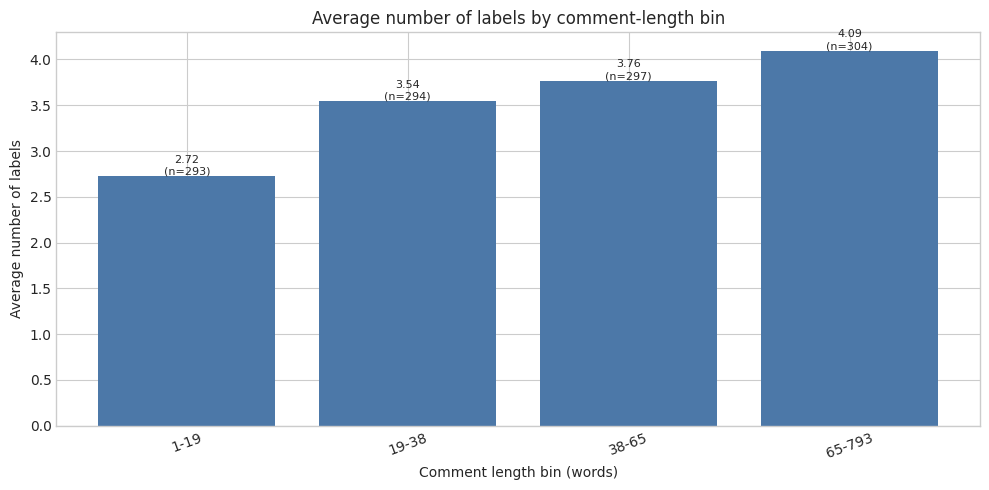

In [23]:
comment_lengths = [len(example.get('text', '').split()) for _, example in all_examples]
label_counts = [len(example.get('gold', {})) for _, example in all_examples]

length_pairs = sorted(zip(comment_lengths, label_counts), key=lambda item: item[0])
length_values = [item[0] for item in length_pairs]
label_values = [item[1] for item in length_pairs]

quantile_edges = [0, 0.25, 0.5, 0.75, 1.0]
cut_points = [length_values[int(round((len(length_values) - 1) * edge))] for edge in quantile_edges]
cut_points[0] = min(length_values)
cut_points[-1] = max(length_values)

bin_labels = []
mean_labels = []
comment_counts = []
for index in range(len(cut_points) - 1):
    left_edge = cut_points[index]
    right_edge = cut_points[index + 1]
    if index == len(cut_points) - 2:
        bin_values = [label for length, label in length_pairs if left_edge <= length <= right_edge]
    else:
        bin_values = [label for length, label in length_pairs if left_edge <= length < right_edge]
    if bin_values:
        bin_labels.append(f'{left_edge}-{right_edge}')
        mean_labels.append(sum(bin_values) / len(bin_values))
        comment_counts.append(len(bin_values))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(bin_labels, mean_labels, color='#4c78a8')
ax.set_title('Average number of labels by comment-length bin')
ax.set_xlabel('Comment length bin (words)')
ax.set_ylabel('Average number of labels')
ax.tick_params(axis='x', rotation=20)

for bar, mean_value, count_value in zip(bars, mean_labels, comment_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, mean_value, f'{mean_value:.2f}\n(n={count_value})', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## Top words by sentiment

This looks at the most common content words associated with each sentiment label.

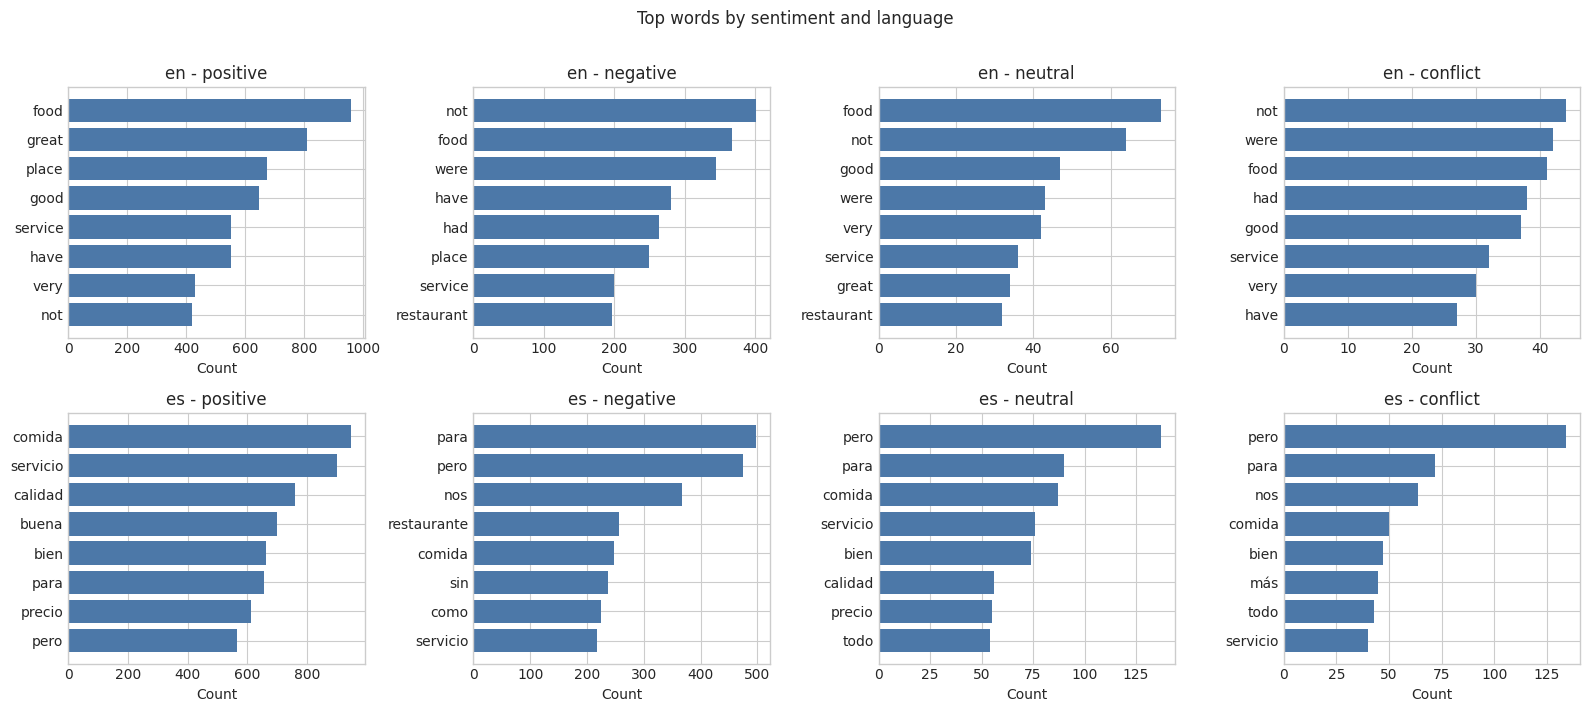

In [20]:
import re

stop_words = {
    'the', 'and', 'a', 'an', 'to', 'of', 'in', 'is', 'it', 'for', 'on', 'with', 'that', 'this', 'was', 'are', 'as', 'but',
    'be', 'at', 'my', 'we', 'you', 'i', 'our', 'they', 'their', 'muy', 'la', 'el', 'de', 'que', 'y', 'en', 'un', 'una', 'lo',
    'los', 'las', 'por', 'con', 'no', 'se', 'es', 'del', 'al', 'su'
}

def tokenize(text):
    return [token.lower() for token in re.findall(r"[A-Za-zÀ-ÿ']+", text) if token.lower() not in stop_words and len(token) > 2]

words_by_language_sentiment = {}
for _, example in all_examples:
    language = example.get('language', 'unknown')
    text = example.get('text', '')
    for sentiment in example.get('gold', {}).values():
        words_by_language_sentiment.setdefault(language, {})
        words_by_language_sentiment[language].setdefault(sentiment, Counter())
        words_by_language_sentiment[language][sentiment].update(tokenize(text))

sentiment_order = ['positive', 'negative', 'neutral', 'conflict']
language_order = sorted(words_by_language_sentiment)
fig, axes = plt.subplots(len(language_order), len(sentiment_order), figsize=(4 * len(sentiment_order), 3.5 * len(language_order)), sharex=False, sharey=False)

if len(language_order) == 1:
    axes = [axes]

for row_index, language in enumerate(language_order):
    for col_index, sentiment in enumerate(sentiment_order):
        axis = axes[row_index][col_index] if len(language_order) > 1 else axes[col_index]
        top_words = words_by_language_sentiment.get(language, {}).get(sentiment, Counter()).most_common(8)
        words = [word for word, _ in top_words]
        counts = [count for _, count in top_words]
        if words:
            axis.barh(words[::-1], counts[::-1], color='#4c78a8')
        axis.set_title(f'{language} - {sentiment}')
        axis.set_xlabel('Count')

fig.suptitle('Top words by sentiment and language', y=1.01)
plt.tight_layout()
plt.show()